Setup & installs

In [ ]:
!pip install faiss-cpu -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.8/18.8 MB 76.1 MB/s eta 0:00:00


Download dataset

In [ ]:
import torchvision
import torchvision.transforms as T

transform = T.Compose([
    T.Resize((224, 224)),  # resize for pretrained ResNet input
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

train_dataset = torchvision.datasets.CIFAR10(root='/content/data', train=True, download=True, transform=transform)
test_dataset = torchvision.datasets.CIFAR10(root='/content/data', train=False, download=True, transform=transform)

class_names = train_dataset.classes
print(f"Train: {len(train_dataset)} | Test: {len(test_dataset)}")
print(f"Classes: {class_names}")

100%|██████████| 170M/170M [46:03<00:00, 61.7kB/s]


Train: 50000 | Test: 10000
Classes: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


Load pretrained feature extractor (ResNet18, no classification head)

In [ ]:
import torch
import torch.nn as nn
import torchvision.models as models

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

resnet = models.resnet18(weights='IMAGENET1K_V1')
feature_extractor = nn.Sequential(*list(resnet.children())[:-1])  # remove final FC layer
feature_extractor = feature_extractor.to(device)
feature_extractor.eval()

print("Feature extractor ready — outputs 512-dim embeddings")

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 209MB/s]


Feature extractor ready — outputs 512-dim embeddings


Build the embedding database (using a subset of train images as the "searchable gallery")

In [ ]:
from torch.utils.data import DataLoader, Subset
import numpy as np
import random

random.seed(42)
GALLERY_SIZE = 3000
gallery_indices = random.sample(range(len(train_dataset)), GALLERY_SIZE)
gallery_subset = Subset(train_dataset, gallery_indices)
gallery_loader = DataLoader(gallery_subset, batch_size=64, shuffle=False, num_workers=2)

gallery_embeddings = []
gallery_labels = []
gallery_images = []

with torch.no_grad():
    for images, labels in gallery_loader:
        images = images.to(device)
        features = feature_extractor(images).squeeze(-1).squeeze(-1)  # (batch, 512)
        gallery_embeddings.append(features.cpu().numpy())
        gallery_labels.extend(labels.numpy())
        gallery_images.extend(images.cpu())

gallery_embeddings = np.vstack(gallery_embeddings)
gallery_labels = np.array(gallery_labels)

print(f"Gallery embeddings shape: {gallery_embeddings.shape}")

Gallery embeddings shape: (3000, 512)


Build FAISS search index

In [ ]:
import faiss

# Normalize embeddings for cosine similarity search
faiss.normalize_L2(gallery_embeddings)

dimension = gallery_embeddings.shape[1]
index = faiss.IndexFlatIP(dimension)  # inner product = cosine similarity after normalization
index.add(gallery_embeddings)

print(f"FAISS index built with {index.ntotal} images")

FAISS index built with 3000 images


Search function

In [ ]:
def search_similar(query_image_tensor, k=5):
    with torch.no_grad():
        query_feat = feature_extractor(query_image_tensor.unsqueeze(0).to(device))
        query_feat = query_feat.squeeze(-1).squeeze(-1).cpu().numpy()

    faiss.normalize_L2(query_feat)
    distances, indices = index.search(query_feat, k)

    return indices[0], distances[0]

Evaluate retrieval quality (Precision@5 using class labels as ground truth)

In [ ]:
NUM_QUERIES = 200
precisions = []

random.seed(1)
query_indices = random.sample(range(len(test_dataset)), NUM_QUERIES)

for qi in query_indices:
    query_img, query_label = test_dataset[qi]
    result_indices, _ = search_similar(query_img, k=5)
    retrieved_labels = gallery_labels[result_indices]
    precision = np.mean(retrieved_labels == query_label)
    precisions.append(precision)

print(f"Precision@5 (avg over {NUM_QUERIES} queries): {np.mean(precisions):.4f}")

Precision@5 (avg over 200 queries): 0.6970


Visualize example queries with top-5 results

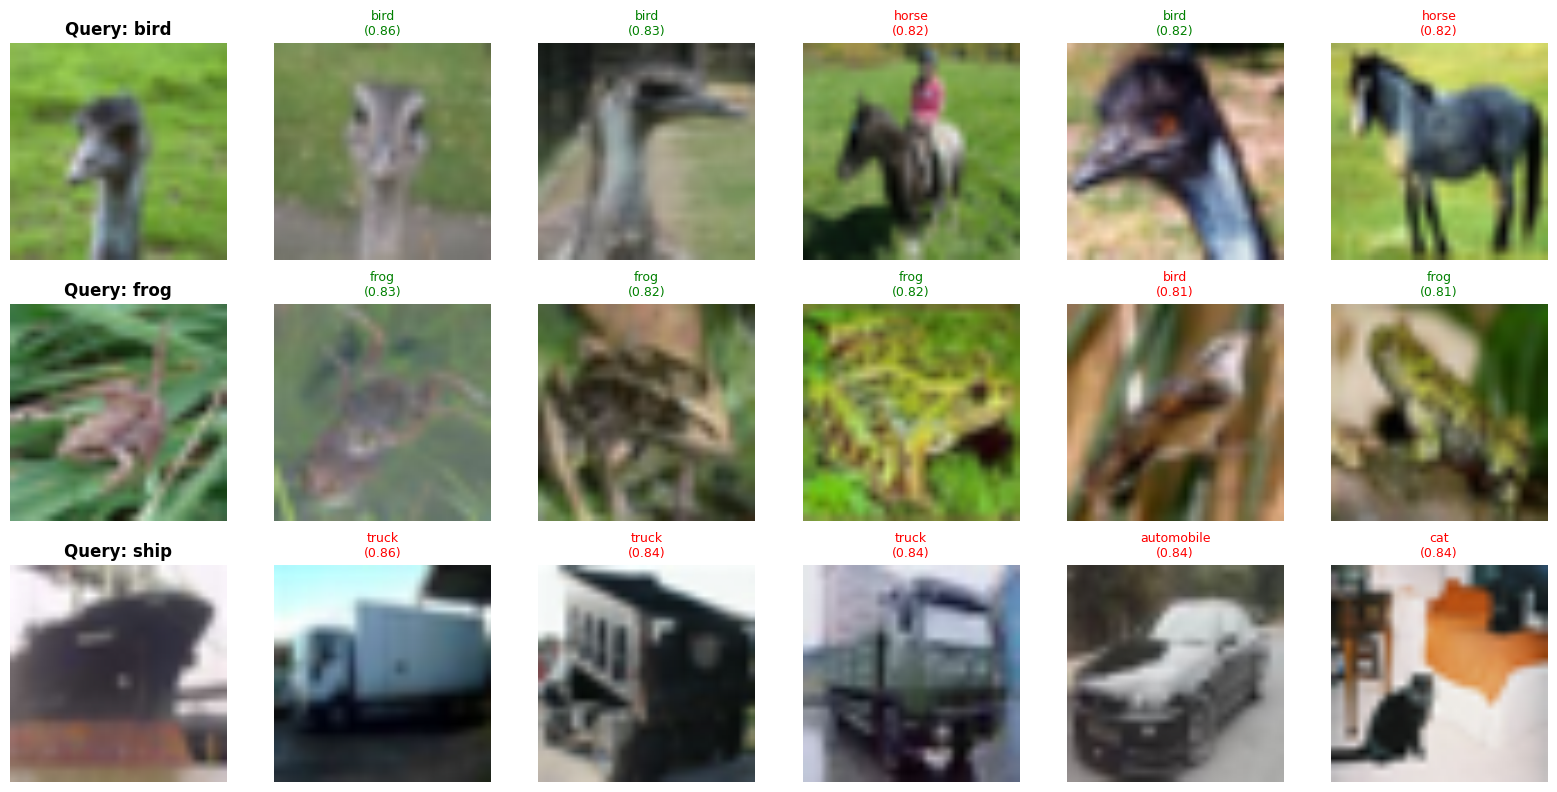

In [ ]:
import matplotlib.pyplot as plt

def denormalize(tensor):
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
    return (tensor * std + mean).clamp(0, 1)

fig, axes = plt.subplots(3, 6, figsize=(16, 8))

sample_queries = random.sample(query_indices, 3)

for row, qi in enumerate(sample_queries):
    query_img, query_label = test_dataset[qi]
    result_indices, distances = search_similar(query_img, k=5)

    axes[row, 0].imshow(denormalize(query_img).permute(1, 2, 0))
    axes[row, 0].set_title(f"Query: {class_names[query_label]}", fontweight='bold')
    axes[row, 0].axis('off')

    for col, idx in enumerate(result_indices):
        result_img = denormalize(gallery_images[idx])
        result_label = class_names[gallery_labels[idx]]
        match_color = 'green' if gallery_labels[idx] == query_label else 'red'

        axes[row, col + 1].imshow(result_img.permute(1, 2, 0))
        axes[row, col + 1].set_title(f"{result_label}\n({distances[col]:.2f})", color=match_color, fontsize=9)
        axes[row, col + 1].axis('off')

plt.tight_layout()
plt.savefig("/content/similarity_search_results.png", dpi=150)
plt.show()

Save embeddings, index, and results for download

In [ ]:
from google.colab import files
import shutil, os

os.makedirs('/content/similarity_bundle', exist_ok=True)

# Save FAISS index
faiss.write_index(index, '/content/similarity_bundle/gallery_index.faiss')

# Save embeddings and labels
np.save('/content/similarity_bundle/gallery_embeddings.npy', gallery_embeddings)
np.save('/content/similarity_bundle/gallery_labels.npy', gallery_labels)

shutil.copy('/content/similarity_search_results.png', '/content/similarity_bundle/')

shutil.make_archive('/content/similarity_bundle', 'zip', '/content/similarity_bundle')
files.download('/content/similarity_bundle.zip')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>